# Grape Disease Detection CNN &Transfer Learning

In this study, a custom CNN built from scratch and a transfer learning architecture were evaluated for classifying grape leaf diseases across four classes using 12,000 images, achieving an optimal real-time species identification model deployed via Streamlit.

<img src='https://ipm.ucanr.edu/PMG/IMAGES/U/D-GR-UCBV-FO.001.jpg' width='750'>

### Libraries

In [1]:
import cv2
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Conv2D,Dense, Flatten, Input, MaxPooling2D, Dropout, BatchNormalization, Reshape
import os

import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.applications import VGG16, VGG19, ResNet50
import warnings
warnings.filterwarnings('ignore')

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rm1000/augmented-grape-disease-detection-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\furka\.cache\kagglehub\datasets\rm1000\augmented-grape-disease-detection-dataset\versions\1


### Reading Dataset

In [3]:
img_path= r"C:\Users\furka\.cache\kagglehub\datasets\rm1000\augmented-grape-disease-detection-dataset\versions\1"

In [4]:
os.listdir(img_path)

['Final Training Data']

In [5]:
real_img_path = r"C:\Users\furka\.cache\kagglehub\datasets\rm1000\augmented-grape-disease-detection-dataset\versions\1\Final Training Data"

In [6]:
os.listdir(real_img_path)

['Black Rot', 'ESCA', 'Healthy', 'Leaf Blight']

In [7]:
labels=['ESCA','Healthy','Leaf Blight','Black Rot']

In [8]:
img_list = []
label_list = []

real_img_path = r"C:\Users\furka\.cache\kagglehub\datasets\rm1000\augmented-grape-disease-detection-dataset\versions\1\Final Training Data"

for label in labels:
    for img_file in os.listdir(os.path.join(real_img_path, label)):
        img_list.append(os.path.join(real_img_path, label, img_file))
        label_list.append(label)

In [9]:
df=pd.DataFrame({'img':img_list,'label':label_list})

In [10]:
df.sample(10)


,img,label
5346,C:\Users\furka\.cache\kagglehub\datasets\rm100...,Healthy
6481,C:\Users\furka\.cache\kagglehub\datasets\rm100...,Leaf Blight
5493,C:\Users\furka\.cache\kagglehub\datasets\rm100...,Healthy
8492,C:\Users\furka\.cache\kagglehub\datasets\rm100...,Leaf Blight
8271,C:\Users\furka\.cache\kagglehub\datasets\rm100...,Leaf Blight
10595,C:\Users\furka\.cache\kagglehub\datasets\rm100...,Black Rot
1214,C:\Users\furka\.cache\kagglehub\datasets\rm100...,ESCA
4432,C:\Users\furka\.cache\kagglehub\datasets\rm100...,Healthy
2748,C:\Users\furka\.cache\kagglehub\datasets\rm100...,ESCA
9300,C:\Users\furka\.cache\kagglehub\datasets\rm100...,Black Rot


In [11]:
d={'ESCA':0,'Healthy':1,'Leaf Blight':2,'Black Rot':3}

In [12]:
df['label_encoded']=df['label'].map(d)

In [13]:
df.sample()


,img,label,label_encoded
10076,C:\Users\furka\.cache\kagglehub\datasets\rm100...,Black Rot,3


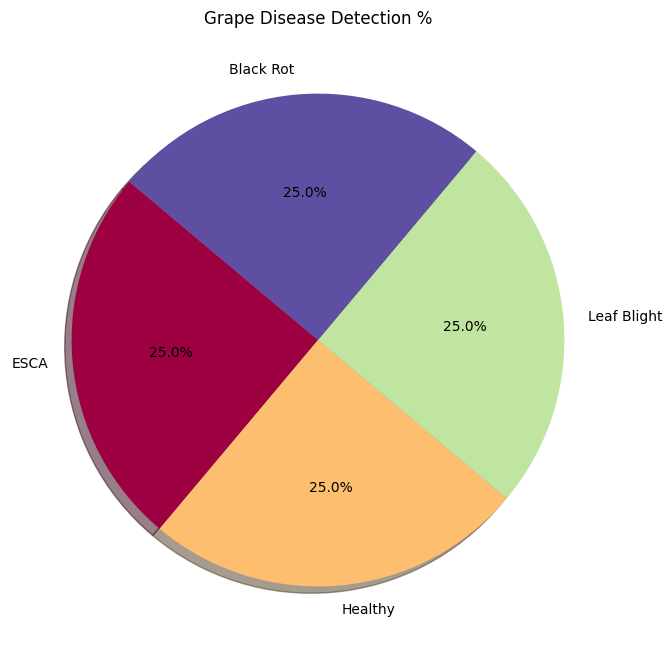

In [14]:
plt.figure(figsize=(10, 8))
df['label'].value_counts().plot.pie(autopct='%1.1f%%', shadow=True, cmap='Spectral', startangle=140)
plt.title("Grape Disease Detection %")
plt.ylabel('')
plt.show()

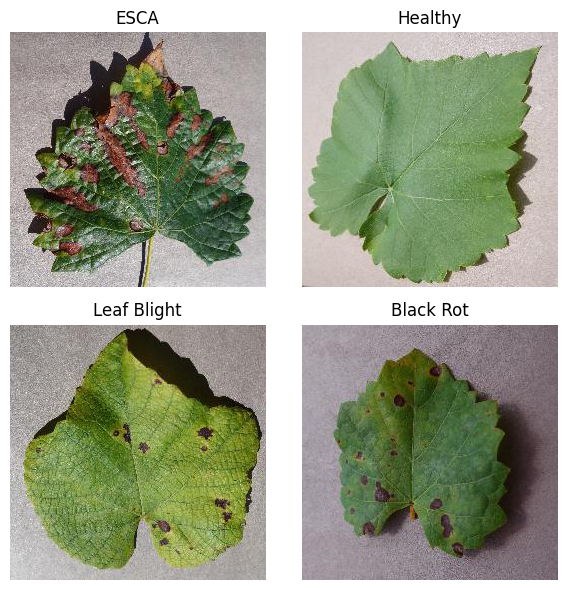

In [15]:
from PIL import Image
images = []
for label in labels:
    img_path = df[df['label'] == label]['img'].iloc[0]
    image = Image.open(img_path)
    images.append((image, label))
plt.figure(figsize=(6,6))
for i, (image, label) in enumerate(images):
    plt.subplot(2, 2, i + 1)
    plt.imshow(image)
    plt.title(label)    
    plt.axis('off')
plt.tight_layout()
plt.show()

### DATA Processing

In [16]:
x=[]
for img in df['img']:
    img=cv2.imread(str(img))
    img=cv2.resize(img,(170,170))
    img=img/255.0
    x.append(img)

In [17]:
x = np.array(x)

In [18]:
x.shape

(12000, 170, 170, 3)

In [19]:
y=df[['label_encoded']]

### CNN Modelling

In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.2,random_state=42)

In [21]:
from tensorflow.keras.layers import Input
model = Sequential()

model.add(Input(shape=(170,170,3)))

model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))


model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(25, activation='softmax'))

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [22]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

In [23]:
history = model.fit(x_train, y_train,validation_data=(x_test, y_test),epochs=25,batch_size=32,callbacks=[early_stop])

Epoch 1/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 1438s 5s/step - accuracy: 0.6736 - loss: 3.1274 - val_accuracy: 0.3288 - val_loss: 14.0626
Epoch 2/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 1459s 5s/step - accuracy: 0.7332 - loss: 0.7481 - val_accuracy: 0.6150 - val_loss: 2.4699
Epoch 3/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 1444s 5s/step - accuracy: 0.7559 - loss: 0.6867 - val_accuracy: 0.5396 - val_loss: 3.5356
Epoch 4/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 1436s 5s/step - accuracy: 0.8046 - loss: 0.5751 - val_accuracy: 0.8871 - val_loss: 0.2770
Epoch 5/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 1399s 5s/step - accuracy: 0.8207 - loss: 0.5239 - val_accuracy: 0.6358 - val_loss: 4.1069
Epoch 6/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 1288s 4s/step - accuracy: 0.8447 - loss: 0.4210 - val_accuracy: 0.7504 - val_loss: 0.7688
Epoch 7/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 1366s 5s/step - accuracy: 0.8895 - loss: 0.3446 - val_accuracy: 0.4325 - val_loss: 9.6390
Epoch 8/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 1501s 5s/step - accuracy: 0.9067 - loss: 0.2840 -

In [26]:
history.history['accuracy'][-1]

0.9172916412353516

In [24]:
model.save("grape_disease.keras")

### Model Interpretation

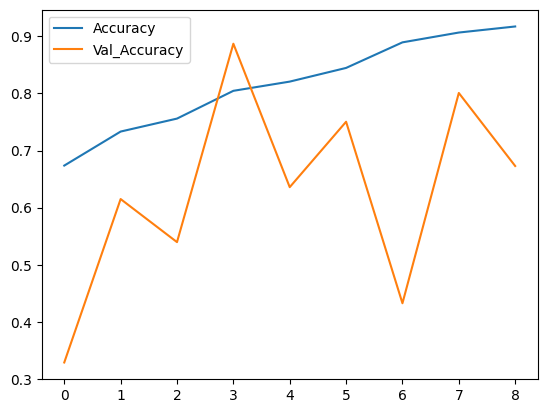

In [27]:
plt.plot(history.history['accuracy'],label='Accuracy')
plt.plot(history.history['val_accuracy'],label='Val_Accuracy')
plt.legend();

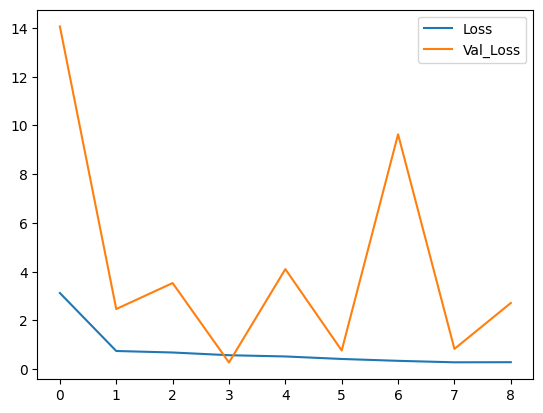

In [28]:
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Val_Loss')
plt.legend();

### Transfer Learning

In [29]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.optimizers import Adam

In [31]:
data_dir = r"C:\Users\furka\.cache\kagglehub\datasets\rm1000\augmented-grape-disease-detection-dataset\versions\1\Final Training Data"
img_size = 224

datagen = ImageDataGenerator(preprocessing_function=preprocess_input,validation_split=0.20)

train_gen = datagen.flow_from_directory(data_dir,target_size=(img_size, img_size),class_mode='sparse',subset='training',shuffle=True)
val_gen = datagen.flow_from_directory(data_dir,target_size=(img_size, img_size),class_mode='sparse',subset='validation',shuffle=False)

Found 9600 images belonging to 4 classes.
Found 2400 images belonging to 4 classes.


In [32]:
base_model = MobileNetV2(weights='imagenet',include_top=False,input_shape=(img_size, img_size, 3))
base_model.trainable = False

In [33]:
from tensorflow.keras.layers import (Dense,Dropout,GlobalAveragePooling2D)
model=Sequential()
model.add(base_model)  
model.add(GlobalAveragePooling2D())
model.add(Dense(512,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(25,activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.0001),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [34]:
early_stop = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

In [35]:
history2=model.fit(train_gen,epochs=50,validation_data=val_gen, callbacks=[early_stop])

Epoch 1/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 227s 740ms/step - accuracy: 0.8632 - loss: 0.4171 - val_accuracy: 0.9800 - val_loss: 0.0709
Epoch 2/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 220s 733ms/step - accuracy: 0.9704 - loss: 0.0913 - val_accuracy: 0.9833 - val_loss: 0.0538
Epoch 3/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 220s 733ms/step - accuracy: 0.9828 - loss: 0.0587 - val_accuracy: 0.9858 - val_loss: 0.0463
Epoch 4/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 220s 734ms/step - accuracy: 0.9860 - loss: 0.0447 - val_accuracy: 0.9887 - val_loss: 0.0419
Epoch 5/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 220s 734ms/step - accuracy: 0.9883 - loss: 0.0362 - val_accuracy: 0.9883 - val_loss: 0.0394
Epoch 6/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 219s 731ms/step - accuracy: 0.9918 - loss: 0.0288 - val_accuracy: 0.9883 - val_loss: 0.0397
Epoch 7/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 216s 720ms/step - accuracy: 0.9931 - loss: 0.0253 - val_accuracy: 0.9879 - val_loss: 0.0383
Epoch 8/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 216s 720ms/step - accuracy: 0.9944 -

In [36]:
history2.history['accuracy'][-1]

0.9992708563804626

### Model Interpretation

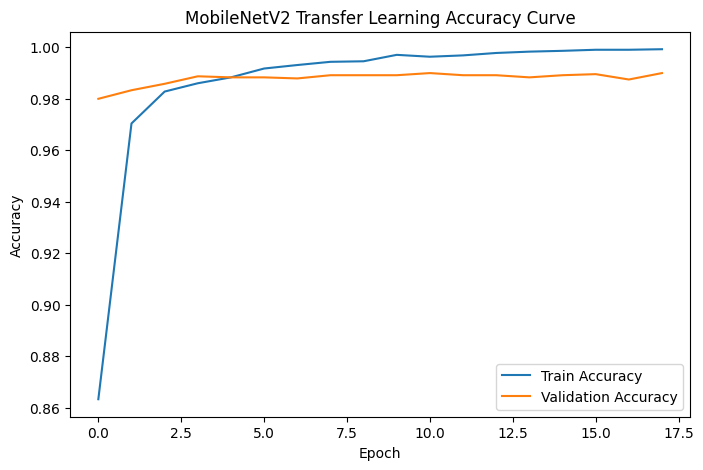

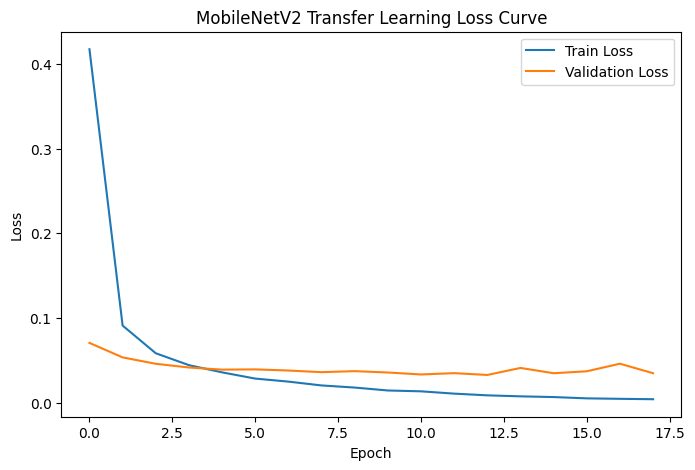

In [37]:
# Accurancy
plt.figure(figsize=(8,5))
plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')

plt.title("MobileNetV2 Transfer Learning Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')

plt.title("MobileNetV2 Transfer Learning Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Confusion Matrix

75/75 ━━━━━━━━━━━━━━━━━━━━ 75s 1000ms/step


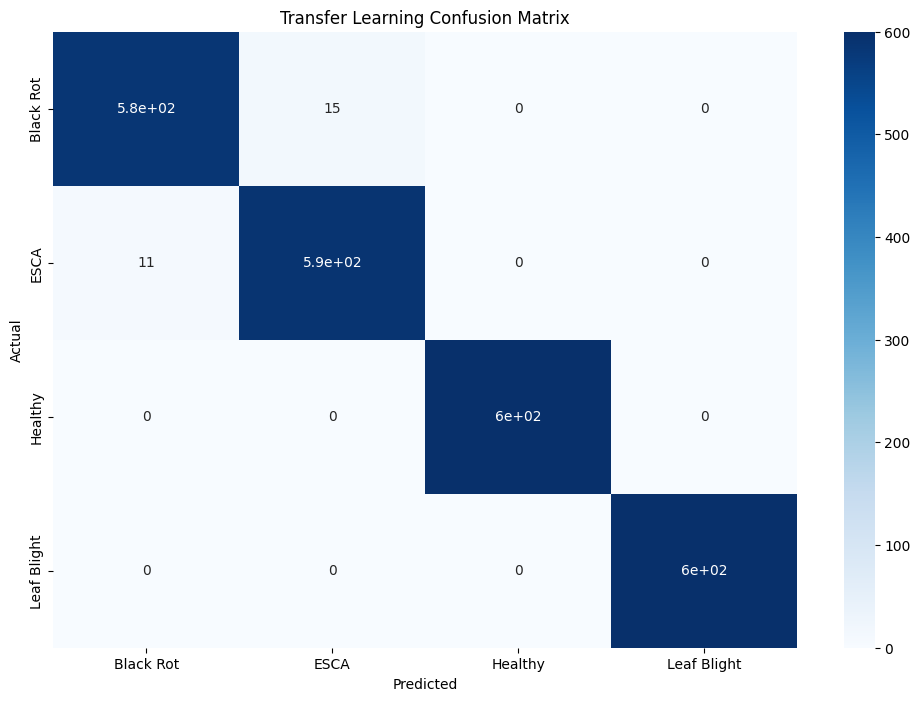

In [41]:
from sklearn.metrics import confusion_matrix
predict= model.predict(val_gen)
predict = np.argmax(predict, axis=1)

y_test = val_gen.classes

labels = list(val_gen.class_indices.keys())

plt.figure(figsize=(12,8))
sns.heatmap(confusion_matrix(y_test, predict),annot=True,cmap='Blues',xticklabels=labels,yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Transfer Learning Confusion Matrix")
plt.show()

In [42]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │         655,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 25)                  │          12,825 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,264,077 (16.27 MB)

 Trainable params: 668,697 (2.55 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 1,337,396 (5.10 MB)

### Conclusion& Evaluation

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step


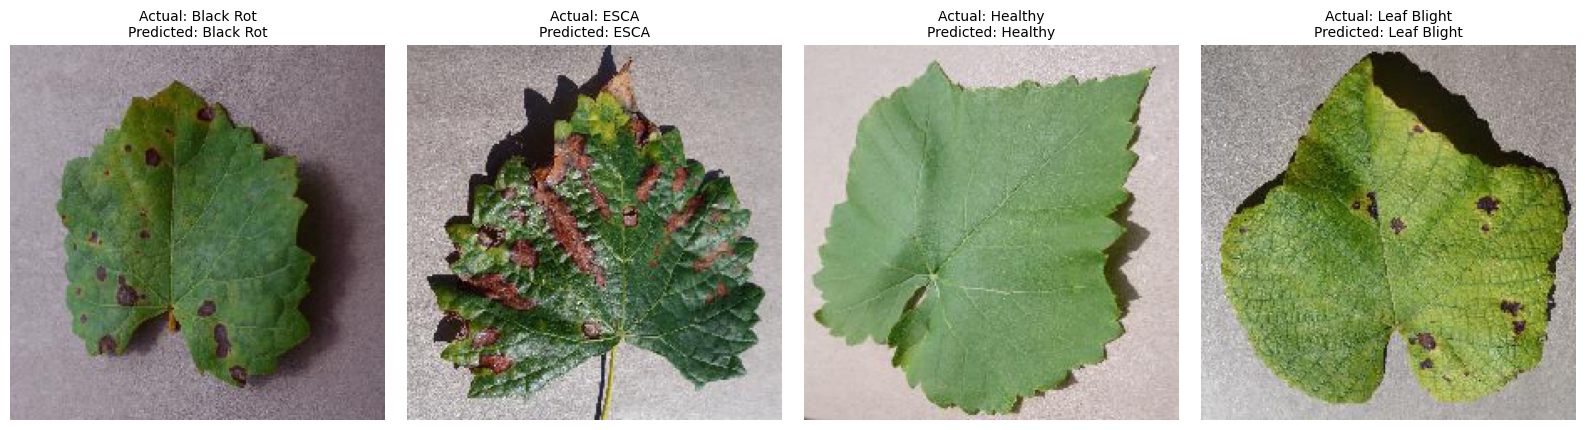

In [44]:
import numpy as np
import matplotlib.pyplot as plt

val_gen.reset()

x_all = []
y_all = []

for i in range(len(val_gen)):
    x_batch, y_batch = val_gen[i]
    x_all.append(x_batch)
    y_all.append(y_batch)

x_all = np.vstack(x_all)
y_all = np.hstack(y_all)

class_names = list(val_gen.class_indices.keys())
num_classes = len(class_names)

plt.figure(figsize=(20,20))

for class_id in range(num_classes):
    
    
    idx = np.where(y_all == class_id)[0][0]
    
    img_display = (x_all[idx] + 1) / 2
    img_display = np.clip(img_display, 0, 1)
    
    prediction = model.predict(np.expand_dims(x_all[idx], axis=0))
    predicted_label = np.argmax(prediction)
    
    plt.subplot(5,5,class_id+1)
    plt.imshow(img_display)
    plt.title(
        f"Actual: {class_names[class_id]}\nPredicted: {class_names[predicted_label]}",
        fontsize=10
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

In [45]:
model.save('grape_disease_transferlearning.keras')

In [46]:
import json
labels_dict = {v: k for k, v in train_gen.class_indices.items()}
with open('labels.json', 'w') as f:
    json.dump(labels_dict, f)

In this project, I conducted a comparative evaluation of two different Deep Learning approaches for grape disease detection:

Custom CNN Architecture: I first built a baseline Convolutional Neural Network (CNN) operating on $170 \times 170$ pixel inputs. This custom model achieved a solid baseline accuracy of 91%.

Transfer Learning (MobileNetV2): To push performance further, I upscaled the input resolution to $224 \times 224$ pixels and implemented the pre-trained MobileNetV2 architecture. By utilizing Transfer Learning alongside feature-specific preprocess_input optimizations, the model achieved an outstanding 99% accuracy rate, successfully concluding the project.